In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

**Ejercicio 17.** Las ecuaciones de movimiento para una partícula de masa \(m\) cargada con una carga \(q\) en un campo magnético \(\vec{B}\) son las ecuaciones de Lorentz:

$$
\vec{F} = q(\vec{v} \times \vec{B})
$$

que pueden descomponerse en términos de posición y velocidad como:

$$
\dot{x}(t)=v_x(t)
$$

$$
\dot{y}(t)=v_y(t)
$$

$$
\dot{z}(t)=v_z(t)
$$

$$
\dot{v}_x(t)=\frac{q}{m}\left(v_y B_z - v_z B_y\right)
$$

$$
\dot{v}_y(t)=\frac{q}{m}\left(v_z B_x - v_x B_z\right)
$$

$$
\dot{v}_z(t)=\frac{q}{m}\left(v_x B_y - v_y B_x\right),
$$

donde los subíndices \(x,y,z\) indican la coordenada del vector correspondiente (\(\vec{v}\) ó \(\vec{B}\)).

Considerar una partícula de masa \(m=0{,}5\,\mathrm{Kg}\) cargada con carga \(q=1\,\mathrm{C}\) sometida a un campo magnético estático a lo largo del eje \(Z\)

$$
\vec{B}=(0,0,B)
$$

con

$$
B=0{,}11\,\mathrm{Kgs^{-1}C^{-1}}.
$$

Suponga que la velocidad inicial de la partícula es

$$
\vec{v}=(v,0,0),
$$

con

$$
v=0{,}1\,\mathrm{ms^{-1}}.
$$

(a) Simular el sistema.

(b) Verificar que la partícula describe una trayectoria circular en el plano \(z=0\).

In [ ]:
def sistema(t, estado, B, q, m):
    
    x, y, z, vx, vy, vz = estado
    Bx, By, Bz = B
    
    dxdt = vx
    dydt = vy
    dzdt = vz
    
    dvxdt = (q/m) * (vy*Bz - vz*By)
    dvydt = (q/m) * (vz*Bx - vx*Bz)
    dvzdt = (q/m) * (vx*By - vy*Bx)
    
    return np.array([dxdt, dydt, dzdt, dvxdt, dvydt, dvzdt], dtype=float)


    
    

In [2]:
def euler(pos_inicial, vel_inicial, B, q, m, t0, tf, h):
    
    # Número de pasos + vector tiempos
    
    num_pasos = int((tf-t0) / h)
    t = np.linspace(t0, tf, num_pasos+1)
    
    # Soluciones
    
    X = np.zeros((num_pasos+1, 3))
    V = np.zeros((num_pasos+1, 3))
    
    # Condiciones iniciales
    
    X[0] = pos_inicial
    V[0] = vel_inicial
    
    for i in range(num_pasos):
        X[i+1] = X[i] + h * V[i]
        V[i+1] = V[i] + h * (q/m) * np.cross(V[i], B)
        
    return t, X, V

In [37]:
pos_inicial = np.array([0, 0, 0])
vel_inicial = np.array([0.1, 0, 0])
B = np.array([0, 0, 0.11])

t, X, V = euler(pos_inicial, vel_inicial, B, 1, 0.5, 0, 32, 0.01)

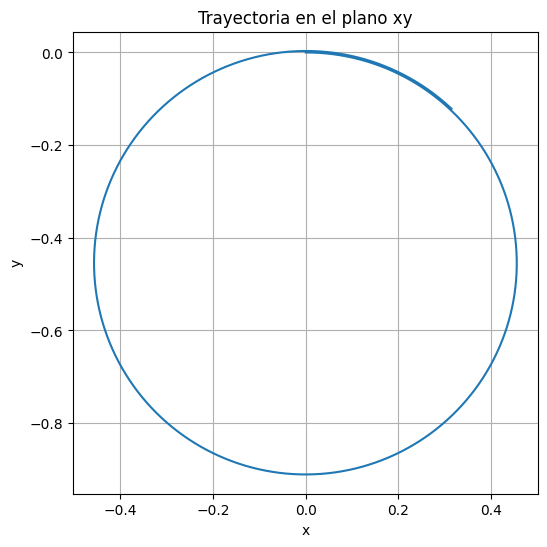

In [38]:
plt.figure(figsize=(6,6))
plt.plot(X[:,0],X[:,1])
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Trayectoria en el plano xy')
plt.axis('equal')
plt.grid()
plt.show()

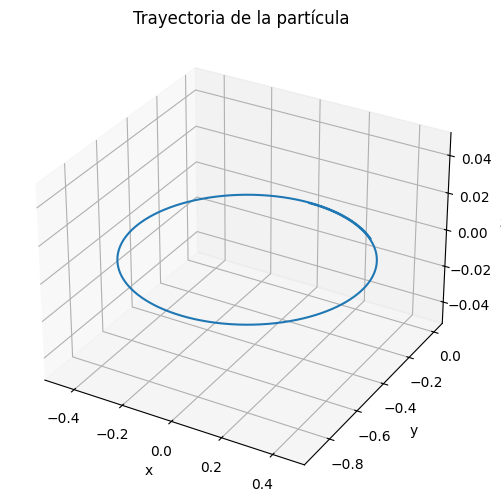

In [39]:
x = X[:, 0]
y = X[:, 1]
z = X[:, 2]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Trayectoria de la partícula')

plt.show()

(c) Calcular el tiempo que tarda la partícula en dar una vuelta.

(d) ¿Qué sucede si se cambia el signo de la velocidad inicial?

(e) Realizar experimentos y conjeturar cómo cambia el período en función de la velocidad inicial.

In [40]:
pos_inicial = np.array([0, 0, 0]) 
contador_vueltas = 0
momento = []


for i in range(len(t)):
    pos_actual = X[i]
    
    if np.array_equal(pos_actual, pos_inicial):
        contador_vueltas +=1
        momento.append(t[i])
        
        
        
print(f'La partícula completa una vuelta en {momento}')

La partícula completa una vuelta en [np.float64(0.0)]
